# Tutorial: Multiple Myeloma Datasets
## Notebook 03 — Per-Patient Diagnosis with PCMMD

This notebook goes one step further than cell-level detection: it uses a trained detector to make a **patient-level clinical diagnosis** on **Dataset 2 (PCMMD)** (Andrade et al., 2025, *Scientific Data*).

**What you will learn:**
- How to train a **2-class** detector (plasma cell vs. non-plasma cell) with YOLO26
- How to keep an entire patient population held out from training, for a realistic diagnostic evaluation
- How to aggregate per-image detections into a **per-patient plasma cell percentage**
- How to turn that percentage into a **diagnosis** using the classic clinical threshold (>10% plasma cells)
- How to measure diagnostic accuracy against ground-truth patient labels

**Clinical context (recap from Notebook 01):** Multiple Myeloma is diagnosed when the bone marrow aspirate shows a plasma cell proportion **greater than 10%**. PCMMD provides real per-patient data with this exact ground truth, making it possible to simulate an end-to-end, AI-assisted diagnostic pipeline.

---
## 0. Environment Setup

In [1]:
!pip install -q ultralytics

In [2]:
import os
import subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 9

DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'Environment configured. Training device: {device_name}')

Environment configured. Training device: NVIDIA T600 Laptop GPU


---
## Part 1 — Dataset Preparation
### 1.1 Download Dataset 2 (PCMMD / MMDB, if needed)

Same source used in `01_image_presentation.ipynb`: the MMDB repository, cloned from GitHub.

In [3]:
DS2_DIR = DATA_DIR / 'MMDB'

if not DS2_DIR.exists():
    print('Cloning MMDB repository...')
    result = subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/LabIA-UFBA/MMDB.git',
         str(DS2_DIR)],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print('Clone complete.')
    else:
        print('Clone error:')
        print(result.stderr)
else:
    print(f'Repository already available at {DS2_DIR}')

DET_DIR = DS2_DIR / 'data' / 'detection'


Repository already available at data/MMDB


### 1.2 Understand the Detection Layout

The detection data has two parts:
- **`train/`** — 512 pooled images with 5 pre-defined folds (`split_1.txt` … `split_5.txt`), meant for model training and validation.
- **`patients/`** — one folder per real patient (10 total), **never used for training**. Each patient folder also has ground-truth annotations, and the repository ships a `diagnosis.csv` with the resulting clinical diagnosis for each one.

We will train on folds 1-4, validate on fold 5, and reserve all 10 patients exclusively for the final diagnosis step.

In [4]:
ground_truth = pd.read_csv(DET_DIR / 'patients' / 'diagnosis.csv')
ground_truth

,patient,plasma_cells,non_plasma_cells,total,percentage,diagnosis
0,1,82,120,202,0.406,diseased
1,2,78,127,205,0.374,diseased
2,3,72,128,200,0.360,diseased
3,4,82,116,198,0.414,diseased
4,5,71,129,200,0.355,diseased
5,6,15,185,200,0.075,normal
6,7,18,187,205,0.088,normal
7,8,9,199,208,0.043,normal
8,9,14,188,202,0.069,normal
9,10,15,188,203,0.074,normal


`diagnosis.csv` was built directly from the ground-truth boxes: `percentage = plasma_cells / total`, and `diagnosis = 'diseased'` whenever `percentage > 0.10`. We will try to reproduce these numbers using a trained model's predictions instead of the ground-truth boxes.

### 1.3 Build the Training/Validation Split

`split_1.txt` … `split_5.txt` list image paths relative to `DET_DIR`. We combine folds 1-4 into a training list and keep fold 5 as validation, writing absolute paths so the config works regardless of the notebook's working directory.

In [5]:
def build_absolute_list(det_dir, split_files, out_path):
    """Write an absolute-path image list file from one or more split_N.txt files."""
    lines = []
    for split_file in split_files:
        for line in (det_dir / split_file).read_text().splitlines():
            line = line.strip()
            if line:
                lines.append(str((det_dir / line).resolve()))
    out_path.write_text('\n'.join(lines) + '\n')
    return len(lines)


TRAIN_LIST = DET_DIR / 'train_folds_1_4.txt'
VAL_LIST = DET_DIR / 'val_fold_5.txt'

n_train = build_absolute_list(DET_DIR, ['split_1.txt', 'split_2.txt', 'split_3.txt', 'split_4.txt'], TRAIN_LIST)
n_val = build_absolute_list(DET_DIR, ['split_5.txt'], VAL_LIST)

print(f'Training images (folds 1-4): {n_train}')
print(f'Validation images (fold 5) : {n_val}')
print(f'Patients held out entirely : {len(sorted((DET_DIR / "patients").glob("patient *")))}')

Training images (folds 1-4): 410
Validation images (fold 5) : 102
Patients held out entirely : 10


### 1.4 Write the `data.yaml` Config

Two classes this time: `Plasma Cell` and `Non-Plasma Cell` (PCMMD annotates both, unlike the single-class fold used in Notebook 02).

In [6]:
DATA_YAML = DET_DIR / 'data.yaml'

data_yaml_content = f'''train: {TRAIN_LIST.resolve()}
val: {VAL_LIST.resolve()}

nc: 2
names: ['Plasma Cell', 'Non-Plasma Cell']
'''

DATA_YAML.write_text(data_yaml_content)
print(f'Config written to {DATA_YAML}\n')
print(data_yaml_content)

Config written to data/MMDB/data/detection/data.yaml

train: /home/rios/projects/tutorial-MM/data/MMDB/data/detection/train_folds_1_4.txt
val: /home/rios/projects/tutorial-MM/data/MMDB/data/detection/val_fold_5.txt

nc: 2
names: ['Plasma Cell', 'Non-Plasma Cell']



---
## Part 2 — Training a 2-Class Detector

Same recipe as Notebook 02 (YOLO26 nano, 25 epochs, 640px) — proven to converge well in a short, live-runnable training run.

In [7]:
EPOCHS = 25
IMG_SIZE = 640
BATCH = 8
RUN_NAME = 'pcmmd_yolo26n'

model = YOLO('yolo26n.pt')

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    seed=0,
    name=RUN_NAME,
    exist_ok=True,
    patience=EPOCHS,  # disable early stopping for this short demo run
)

RUN_DIR = Path(results.save_dir)
print(f'\nTraining finished. Artifacts saved to: {RUN_DIR}')

New https://pypi.org/project/ultralytics/8.4.86 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.4.84 🚀 Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA T600 Laptop GPU, 3721MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/MMDB/data/detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pcmmd_yolo26n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=25, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False

Overriding model.yaml nc=80 with nc=2



                   from  n    params  module                                       arguments                     


...

           Plasma Cell        102        323      0.716      0.833      0.843      0.746


       Non-Plasma Cell         70        369      0.649      0.591      0.659       0.52


Speed: 0.3ms preprocess, 11.6ms inference, 0.0ms loss, 0.1ms postprocess per image


Results saved to /home/rios/projects/tutorial-MM/runs/detect/pcmmd_yolo26n



Training finished. Artifacts saved to: /home/rios/projects/tutorial-MM/runs/detect/pcmmd_yolo26n


---
## Part 3 — Training Curves

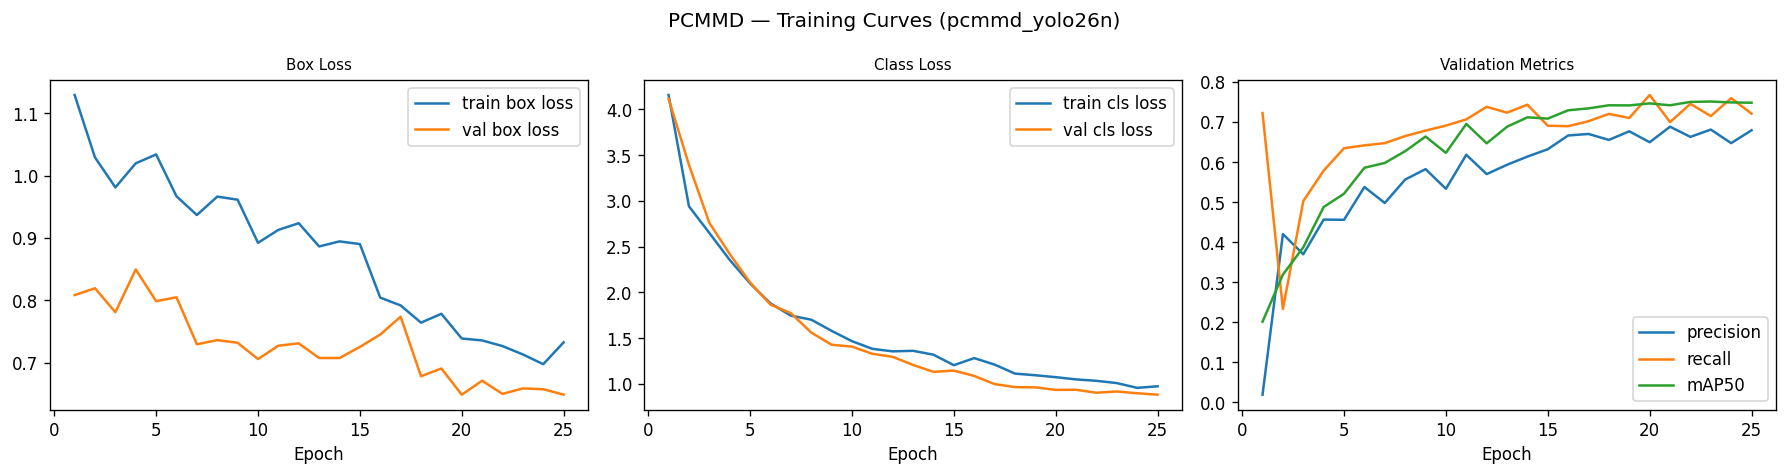

In [8]:
%matplotlib inline
history = pd.read_csv(RUN_DIR / 'results.csv')
history.columns = [c.strip() for c in history.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'PCMMD — Training Curves ({RUN_NAME})', fontsize=12)

axes[0].plot(history['epoch'], history['train/box_loss'], label='train box loss')
axes[0].plot(history['epoch'], history['val/box_loss'], label='val box loss')
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['epoch'], history['train/cls_loss'], label='train cls loss')
axes[1].plot(history['epoch'], history['val/cls_loss'], label='val cls loss')
axes[1].set_title('Class Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['epoch'], history['metrics/precision(B)'], label='precision')
axes[2].plot(history['epoch'], history['metrics/recall(B)'], label='recall')
axes[2].plot(history['epoch'], history['metrics/mAP50(B)'], label='mAP50')
axes[2].set_title('Validation Metrics')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Part 4 — Evaluation on the Held-Out Validation Fold

Fold 5 was never trained on, so it gives an unbiased read of per-class detection quality before we move on to the patient-level diagnosis.

In [9]:
best_model = YOLO(RUN_DIR / 'weights' / 'best.pt')

val_metrics = best_model.val(data=str(DATA_YAML), split='val', device=DEVICE)

print('=== Validation Metrics (per class) ===')
print(f'mAP@50    : {val_metrics.results_dict["metrics/mAP50(B)"]:.3f}')
print(f'mAP@50-95 : {val_metrics.results_dict["metrics/mAP50-95(B)"]:.3f}')
for i, name in val_metrics.names.items():
    print(f'{name:16s}  AP50={val_metrics.box.ap50[i]:.3f}  AP50-95={val_metrics.box.ap[i]:.3f}')

Ultralytics 8.4.84 🚀 Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA T600 Laptop GPU, 3721MiB)


YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4151.4±335.2 MB/s, size: 1456.4 KB)


val: Scanning /home/rios/projects/tutorial-MM/data/MMDB/data/detection/train/labels.cache... 102 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 102/102 22.5Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 14% ━╸────────── 1/7 3.4s/it 1.0s<20.3s

...

           Plasma Cell        102        323      0.716      0.833      0.843      0.746


       Non-Plasma Cell         70        369      0.649      0.591      0.659       0.52


Speed: 2.7ms preprocess, 10.9ms inference, 0.0ms loss, 1.2ms postprocess per image


Results saved to /home/rios/projects/tutorial-MM/runs/detect/val


=== Validation Metrics (per class) ===
mAP@50    : 0.751
mAP@50-95 : 0.633
Plasma Cell       AP50=0.843  AP50-95=0.746
Non-Plasma Cell   AP50=0.659  AP50-95=0.520


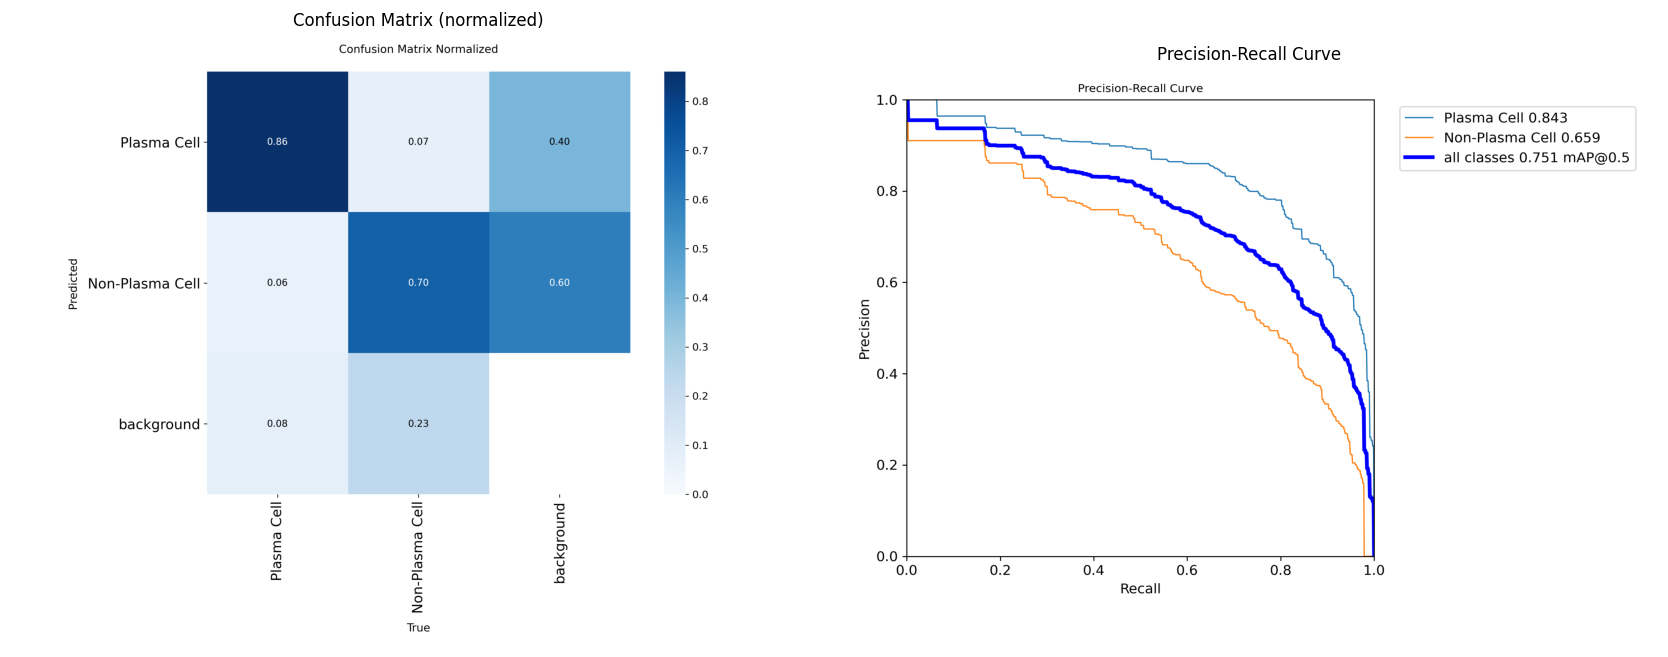

In [10]:
%matplotlib inline
val_run_dir = Path(val_metrics.save_dir)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fname, title in zip(
    axes,
    ['confusion_matrix_normalized.png', 'BoxPR_curve.png'],
    ['Confusion Matrix (normalized)', 'Precision-Recall Curve'],
):
    img_path = val_run_dir / fname
    if img_path.exists():
        ax.imshow(plt.imread(img_path))
        ax.set_title(title, fontsize=10)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Part 5 — Per-Patient Diagnosis

Now for the clinically meaningful part: run the detector on every image of every held-out patient, aggregate the box counts, and derive a diagnosis exactly the way `diagnosis.csv` was built — but from **model predictions** instead of ground-truth boxes.

In [11]:
def load_rgb(path):
    """Read an image and convert it to RGB."""
    img = cv2.imread(str(path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def diagnose_patient(patient_dir, model, conf=0.25, device=DEVICE):
    """Run detection over every image of a patient and count cells per class."""
    images = sorted((patient_dir / 'images').glob('*.jpg'))
    if not images:
        return {'n_images': 0, 'plasma_cells': 0, 'non_plasma_cells': 0}

    results = model.predict(images, conf=conf, device=device, verbose=False)
    plasma = sum(int((r.boxes.cls == 0).sum()) for r in results)
    non_plasma = sum(int((r.boxes.cls == 1).sum()) for r in results)
    return {'n_images': len(images), 'plasma_cells': plasma, 'non_plasma_cells': non_plasma}


PATIENT_THRESHOLD = 0.10  # >10% plasma cells => diseased (see Notebook 01)

patient_dirs = sorted((DET_DIR / 'patients').glob('patient *'))
records = []
for patient_dir in patient_dirs:
    patient_id = int(patient_dir.name.replace('patient', '').strip())
    counts = diagnose_patient(patient_dir, best_model)
    total = counts['plasma_cells'] + counts['non_plasma_cells']
    percentage = counts['plasma_cells'] / total if total else 0.0
    records.append({
        'patient': patient_id,
        'pred_plasma_cells': counts['plasma_cells'],
        'pred_non_plasma_cells': counts['non_plasma_cells'],
        'pred_percentage': percentage,
        'pred_diagnosis': 'diseased' if percentage > PATIENT_THRESHOLD else 'normal',
    })

predictions = pd.DataFrame(records)
predictions

,patient,pred_plasma_cells,pred_non_plasma_cells,pred_percentage,pred_diagnosis
0,1,57,190,0.230769,diseased
1,2,65,177,0.268595,diseased
2,3,61,163,0.272321,diseased
3,4,54,151,0.263415,diseased
4,5,52,158,0.247619,diseased
5,6,5,238,0.020576,normal
6,7,11,285,0.037162,normal
7,8,9,315,0.027778,normal
8,9,12,258,0.044444,normal
9,10,16,247,0.060837,normal


### 5.1 Comparing Predicted vs. Ground-Truth Diagnosis

In [12]:
comparison = ground_truth.merge(predictions, on='patient', suffixes=('_true', '_pred'))
comparison['correct'] = comparison['diagnosis'] == comparison['pred_diagnosis']
comparison = comparison[[
    'patient', 'percentage', 'diagnosis',
    'pred_percentage', 'pred_diagnosis', 'correct'
]].rename(columns={'percentage': 'true_percentage', 'diagnosis': 'true_diagnosis'})

accuracy = comparison['correct'].mean()
print(f'Patient-level diagnostic accuracy: {accuracy:.0%} ({comparison["correct"].sum()}/{len(comparison)})')
comparison

Patient-level diagnostic accuracy: 100% (10/10)


,patient,true_percentage,true_diagnosis,pred_percentage,pred_diagnosis,correct
0,1,0.406,diseased,0.230769,diseased,True
1,2,0.374,diseased,0.268595,diseased,True
2,3,0.360,diseased,0.272321,diseased,True
3,4,0.414,diseased,0.263415,diseased,True
4,5,0.355,diseased,0.247619,diseased,True
5,6,0.075,normal,0.020576,normal,True
6,7,0.088,normal,0.037162,normal,True
7,8,0.043,normal,0.027778,normal,True
8,9,0.069,normal,0.044444,normal,True
9,10,0.074,normal,0.060837,normal,True


In [13]:
print('=== Confusion Matrix (patient-level diagnosis) ===')
print(pd.crosstab(comparison['true_diagnosis'], comparison['pred_diagnosis'],
                   rownames=['True'], colnames=['Predicted'], dropna=False))

=== Confusion Matrix (patient-level diagnosis) ===
Predicted  diseased  normal
True                       
diseased          5       0
normal            0       5


### 5.2 Visualizing the Diagnostic Threshold

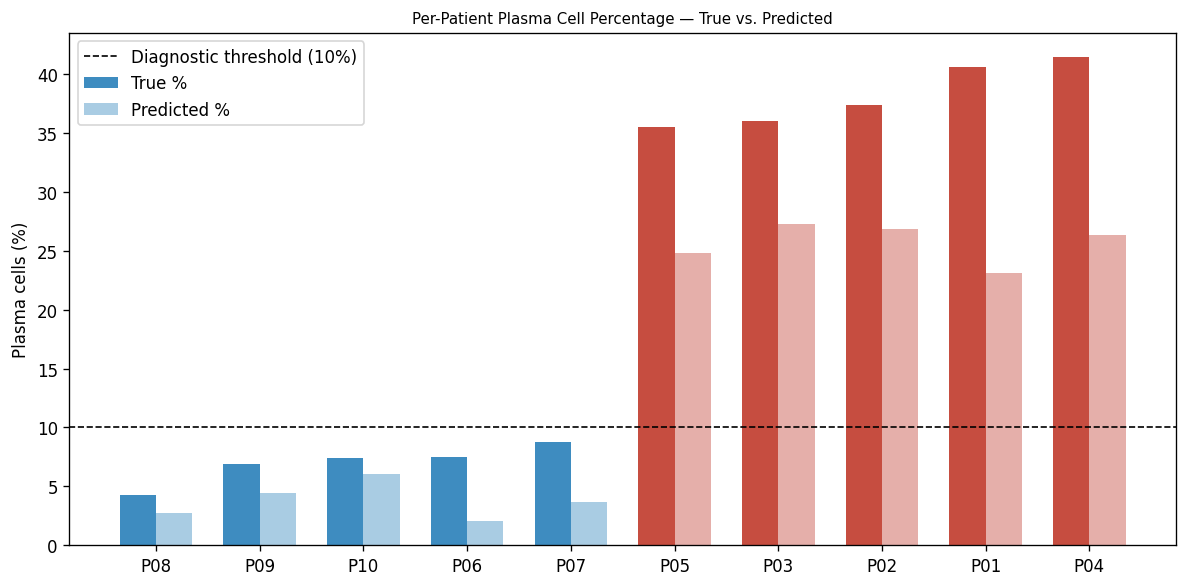

In [14]:
%matplotlib inline
plot_df = comparison.sort_values('true_percentage').reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
colors_true = ['#c0392b' if d == 'diseased' else '#2980b9' for d in plot_df['true_diagnosis']]

ax.bar(x - width / 2, plot_df['true_percentage'] * 100, width, label='True %', color=colors_true, alpha=0.9)
ax.bar(x + width / 2, plot_df['pred_percentage'] * 100, width, label='Predicted %', color=colors_true, alpha=0.4)
ax.axhline(PATIENT_THRESHOLD * 100, color='black', linestyle='--', linewidth=1, label='Diagnostic threshold (10%)')

ax.set_xticks(x)
ax.set_xticklabels([f'P{p:02d}' for p in plot_df['patient']])
ax.set_ylabel('Plasma cells (%)')
ax.set_title('Per-Patient Plasma Cell Percentage — True vs. Predicted')
ax.legend()

plt.tight_layout()
plt.show()

### 5.3 Visual Inspection: One Diseased and One Normal Patient

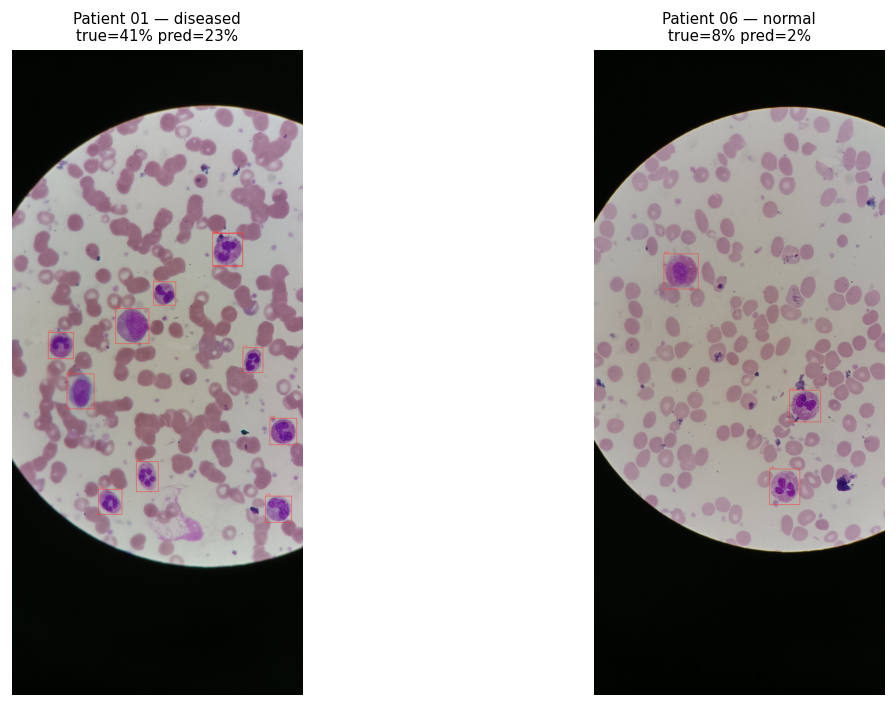

In [15]:
%matplotlib inline
def draw_pred_boxes(img, result, color=(255, 50, 50)):
    """Draw predicted boxes on an image (numpy RGB), labeled with confidence."""
    img_out = img.copy()
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        conf = float(box.conf[0])
        cv2.rectangle(img_out, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_out, f'{conf:.2f}', (x1, max(y1 - 5, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return img_out


example_patients = [
    comparison.loc[comparison['true_diagnosis'] == 'diseased', 'patient'].iloc[0],
    comparison.loc[comparison['true_diagnosis'] == 'normal', 'patient'].iloc[0],
]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, patient_id in zip(axes, example_patients):
    patient_dir = DET_DIR / 'patients' / f'patient {patient_id:02d}'
    img_path = sorted((patient_dir / 'images').glob('*.jpg'))[0]
    img = load_rgb(img_path)
    result = best_model.predict(img_path, conf=0.25, device=DEVICE, verbose=False)[0]
    annotated = draw_pred_boxes(img, result)

    row = comparison[comparison['patient'] == patient_id].iloc[0]
    ax.imshow(annotated)
    ax.set_title(f'Patient {patient_id:02d} — {row.true_diagnosis}\n'
                 f'true={row.true_percentage:.0%} pred={row.pred_percentage:.0%}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Summary

In this notebook you learned how to:

1. **Hold out** an entire patient population from training, for a realistic diagnostic test
2. **Train** a 2-class YOLO26 detector (plasma cell vs. non-plasma cell) on PCMMD
3. **Aggregate** per-image detections into a per-patient plasma cell percentage
4. **Apply** the clinical 10% threshold to turn a percentage into a diagnosis
5. **Measure** patient-level diagnostic accuracy against ground truth

**Limitations to discuss with students:**
- Only 10 patients — the diagnostic accuracy estimate has wide uncertainty
- A single training run / single fold split, not averaged across the 5 folds
- Detection errors compound: a few missed or extra boxes can flip a borderline patient's diagnosis near the 10% threshold

**Ideas to extend this notebook:**
- Repeat the training across all 5 folds and average the per-patient predictions
- Try the segmentation task in PCMMD for pixel-level plasma cell area instead of box counts
- Sweep the confidence threshold used for counting detections and see how it affects diagnostic accuracy

**References:**
- Andrade et al. (2025). *PCMMD*. Scientific Data, 12, 161. https://doi.org/10.1038/s41597-025-04459-1
- Ultralytics YOLO26. https://docs.ultralytics.com/